In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

PROJECT_DIR = "/content/drive/MyDrive/Generalizable-DDA-RL"

os.makedirs(PROJECT_DIR, exist_ok=True)

print("Project directory:", PROJECT_DIR)

Project directory: /content/drive/MyDrive/Generalizable-DDA-RL


### ***Project Structure***

In [4]:
import os

folders = [
    "src",
    "notebooks",
    "configs",
    "models",
    "results",
    "results/figures",
    "results/tables",
    "results/trajectories",
    "docs",
    "paper",
    "paper/figures",
    "paper/tables"
]

for folder in folders:
    os.makedirs(
        os.path.join(PROJECT_DIR, folder),
        exist_ok=True
    )

print("Project Structure Created Successfully :)")

Project Structure Created Successfully :)


In [7]:
%cd /content/drive/MyDrive/Generalizable-DDA-RL

/content/drive/MyDrive/Generalizable-DDA-RL


### ***Required Packages***

In [8]:
!pip install -q gymnasium stable-baselines3 numpy pandas matplotlib scipy scikit-learn pyyaml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 6.0 MB/s eta 0:00:00


In [10]:
import gymnasium
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from stable_baselines3 import PPO
from gymnasium import spaces

print("Gymnasium:", gymnasium.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

print("\nSUCCESS!")

Gymnasium: 1.3.0
NumPy: 2.1.3
Pandas: 2.2.3

SUCCESS!


In [11]:
%%writefile src/player.py

import numpy as np


class SimulatedPlayer:
    """
    Simulated game player.

    The RL agent cannot directly observe true_skill.
    It only receives gameplay telemetry.

    Supports:
    - stable skill
    - learning
    - fatigue
    - noisy performance
    """

    def __init__(
        self,
        initial_skill=0.5,
        learning_rate=0.0,
        fatigue_rate=0.0,
        noise_std=0.05,
        seed=None
    ):

        self.initial_skill = initial_skill
        self.learning_rate = learning_rate
        self.fatigue_rate = fatigue_rate
        self.noise_std = noise_std

        self.rng = np.random.default_rng(seed)

        self.reset()


    def reset(self):

        self.true_skill = float(
            self.initial_skill
        )

        self.step_count = 0

        self.history = []


    def update_skill(self):

        self.step_count += 1

        learning = (
            self.learning_rate
            * self.step_count
        )

        fatigue = (
            self.fatigue_rate
            * self.step_count
        )

        self.true_skill = (
            self.initial_skill
            + learning
            - fatigue
        )

        self.true_skill = float(
            np.clip(
                self.true_skill,
                0.05,
                0.95
            )
        )


    def play(
        self,
        difficulty
    ):

        self.update_skill()

        performance_noise = (
            self.rng.normal(
                0,
                self.noise_std
            )
        )

        effective_skill = np.clip(
            self.true_skill
            + performance_noise,
            0.01,
            0.99
        )

        success_probability = 1 / (
            1
            + np.exp(
                8
                * (
                    difficulty
                    - effective_skill
                )
            )
        )

        success = int(
            self.rng.random()
            < success_probability
        )

        completion_time = (
            1.0
            + difficulty
            - effective_skill
            + abs(
                performance_noise
            )
        )

        completion_time = max(
            completion_time,
            0.1
        )

        error_rate = np.clip(
            difficulty
            - effective_skill
            + abs(
                performance_noise
            ),
            0.0,
            1.0
        )

        result = {

            "success": success,

            "completion_time":
                float(
                    completion_time
                ),

            "error_rate":
                float(
                    error_rate
                ),

            "true_skill":
                float(
                    self.true_skill
                ),

            "success_probability":
                float(
                    success_probability
                )
        }

        self.history.append(
            result
        )

        return result

Writing src/player.py


In [12]:
%%writefile src/__init__.py

#Generalizable DDA RL package

Writing src/__init__.py


### ***Testing Player Simulator***

In [15]:
from src.player import SimulatedPlayer

player = SimulatedPlayer(
    initial_skill=0.5,
    learning_rate=0.0,
    fatigue_rate=0.0,
    noise_std=0.05,
    seed=42
)

result = player.play(
    difficulty=0.5
)

print(result)

{'success': 1, 'completion_time': 1.0, 'error_rate': 3.122502256758253e-17, 'true_skill': 0.5, 'success_probability': 0.5304340389474009}


### ***Creating All Player Types***

In [17]:
from src.player import SimulatedPlayer


players = {

    "Stable":
        SimulatedPlayer(
            initial_skill=0.5,
            learning_rate=0.0,
            fatigue_rate=0.0,
            noise_std=0.05,
            seed=42
        ),

    "Learning":
        SimulatedPlayer(
            initial_skill=0.3,
            learning_rate=0.003,
            fatigue_rate=0.0,
            noise_std=0.05,
            seed=42
        ),

    "Fatigue":
        SimulatedPlayer(
            initial_skill=0.8,
            learning_rate=0.0,
            fatigue_rate=0.002,
            noise_std=0.05,
            seed=42
        ),

    "Noisy":
        SimulatedPlayer(
            initial_skill=0.6,
            learning_rate=0.0,
            fatigue_rate=0.0,
            noise_std=0.15,
            seed=42
        )
}


print("Player Profiles Created Successfully :)\n")

for name in players:
    print("-", name)

Player Profiles Created Successfully :)

- Stable
- Learning
- Fatigue
- Noisy


### ***First Research Figure***

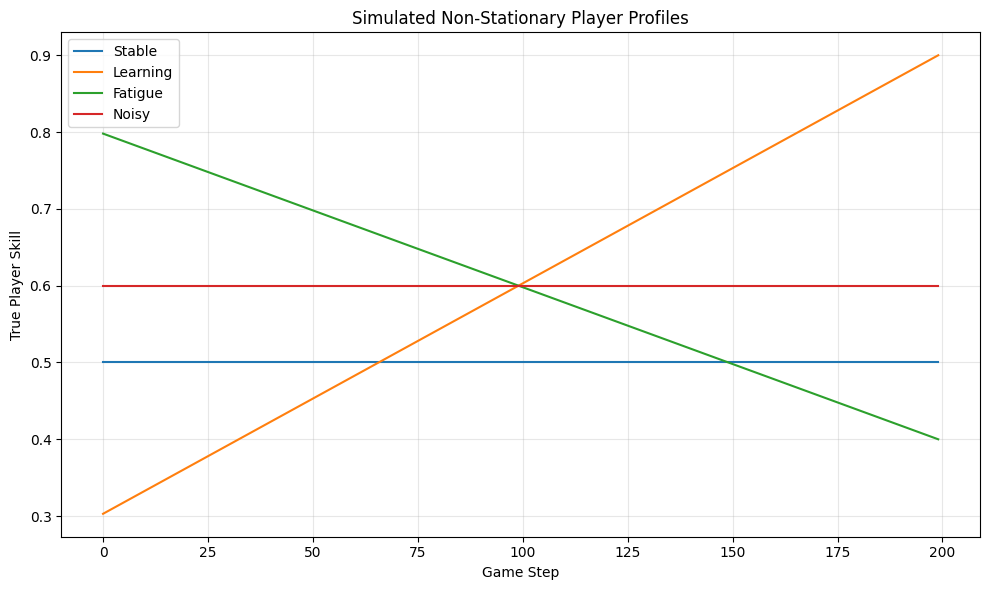

In [18]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 6))


for name, player in players.items():

    skills = []

    player.reset()

    for _ in range(200):

        result = player.play(
            difficulty=0.5
        )

        skills.append(
            result["true_skill"]
        )

    plt.plot(
        skills,
        label=name
    )


plt.xlabel("Game Step")

plt.ylabel("True Player Skill")

plt.title(
    "Simulated Non-Stationary Player Profiles"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

### ***Save!***

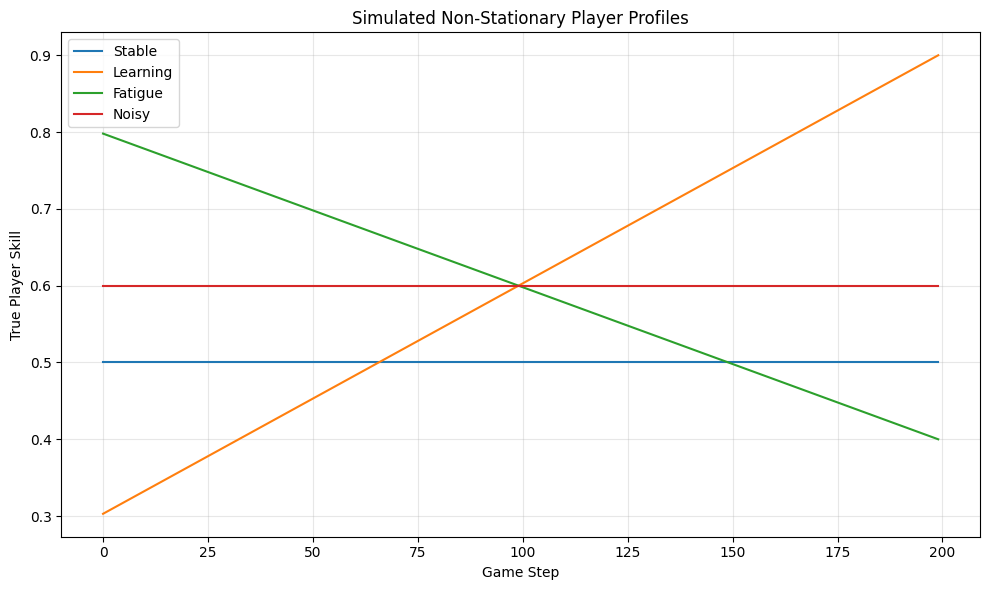

Figure Saved to : results/figures/player_profiles.png


In [19]:
FIGURE_PATH = (
    "results/figures/"
    "player_profiles.png"
)

plt.figure(figsize=(10, 6))


for name, player in players.items():

    skills = []

    player.reset()

    for _ in range(200):

        result = player.play(
            difficulty=0.5
        )

        skills.append(
            result["true_skill"]
        )

    plt.plot(
        skills,
        label=name
    )


plt.xlabel("Game Step")

plt.ylabel("True Player Skill")

plt.title(
    "Simulated Non-Stationary Player Profiles"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Figure Saved to : {FIGURE_PATH}"
)